## 🌳 03 — Decision Tree

**What it does:** Splits data into branches based on feature 
thresholds to make predictions. Like a flowchart.  
**Best used when:** You need an interpretable, explainable model.  
**Dataset:** Iris Flower (built-in sklearn)  
**Algorithm type:** Supervised → Multiclass Classification  
**Key metrics:** Accuracy, Confusion Matrix  
**No feature scaling needed!**  
**Model saved as:** `/decision_tree.pkl`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import os

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({
    0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'
})

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['species'].value_counts())
df.head()

Shape: (150, 6)

Class distribution:
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


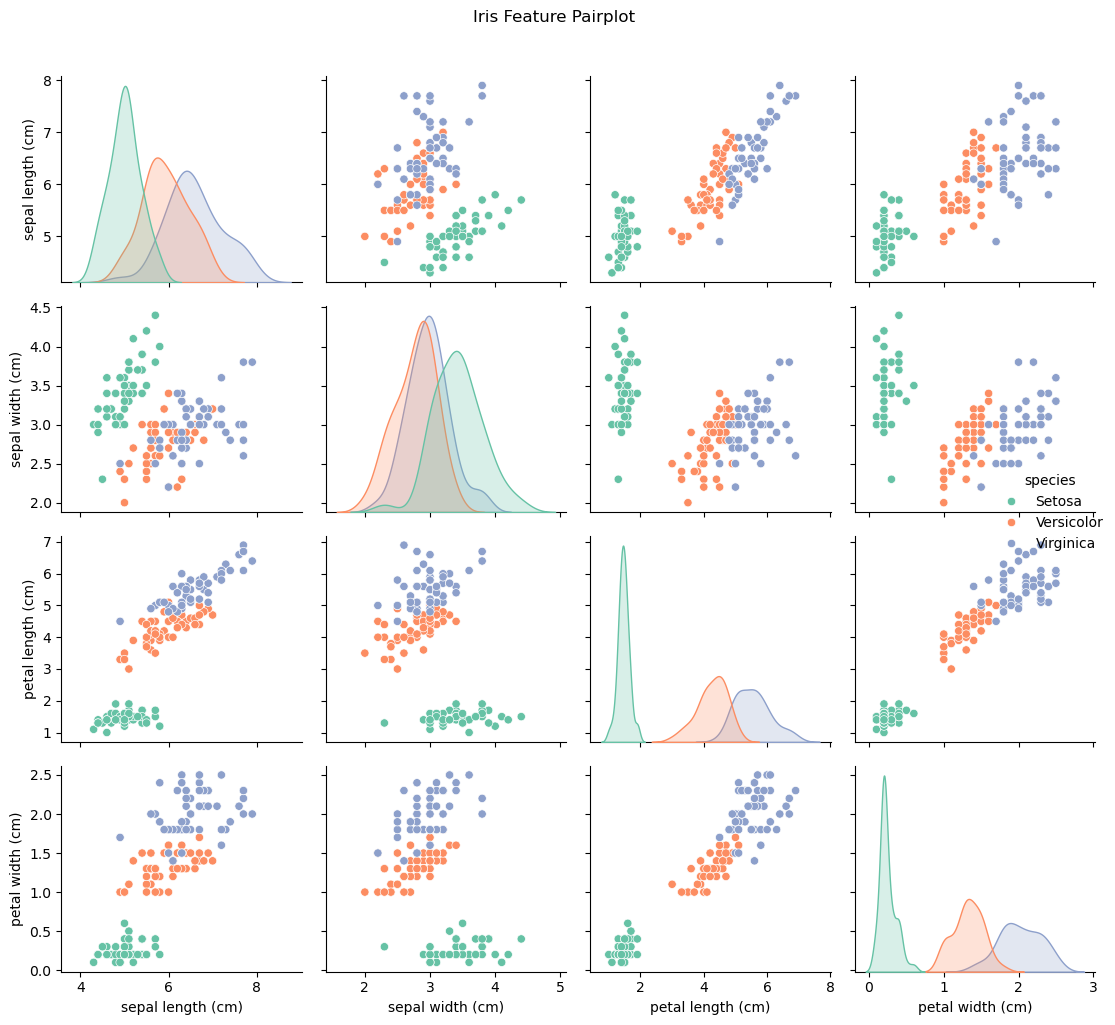

In [4]:
# Pairplot — best way to visualize Iris dataset
sns.pairplot(df, hue='species', vars=iris.feature_names,
             palette='Set2')
plt.suptitle('Iris Feature Pairplot', y=1.02)
plt.tight_layout()
plt.show()

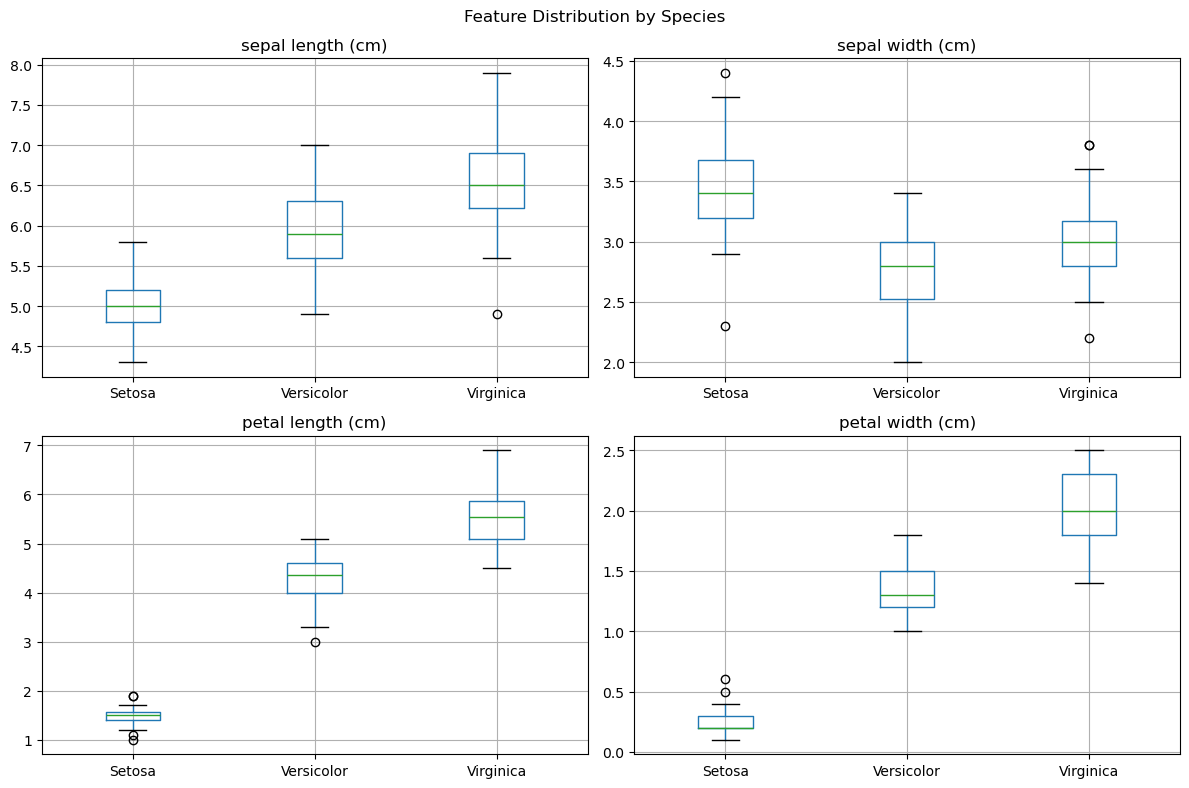

In [5]:
# Boxplot per feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, feature in enumerate(iris.feature_names):
    ax = axes[idx//2][idx%2]
    df.boxplot(column=feature, by='species', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')
plt.suptitle('Feature Distribution by Species')
plt.tight_layout()
plt.show()

In [6]:
X = df[iris.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# max_depth=3 keeps tree readable — not too deep
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully ✅")
print(f"Tree depth: {model.get_depth()}")
print(f"Number of leaves: {model.get_n_leaves()}")

Model trained successfully ✅
Tree depth: 3
Number of leaves: 5


In [7]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=iris.target_names))

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



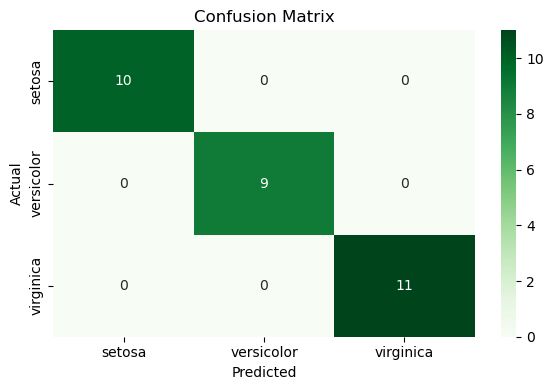

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

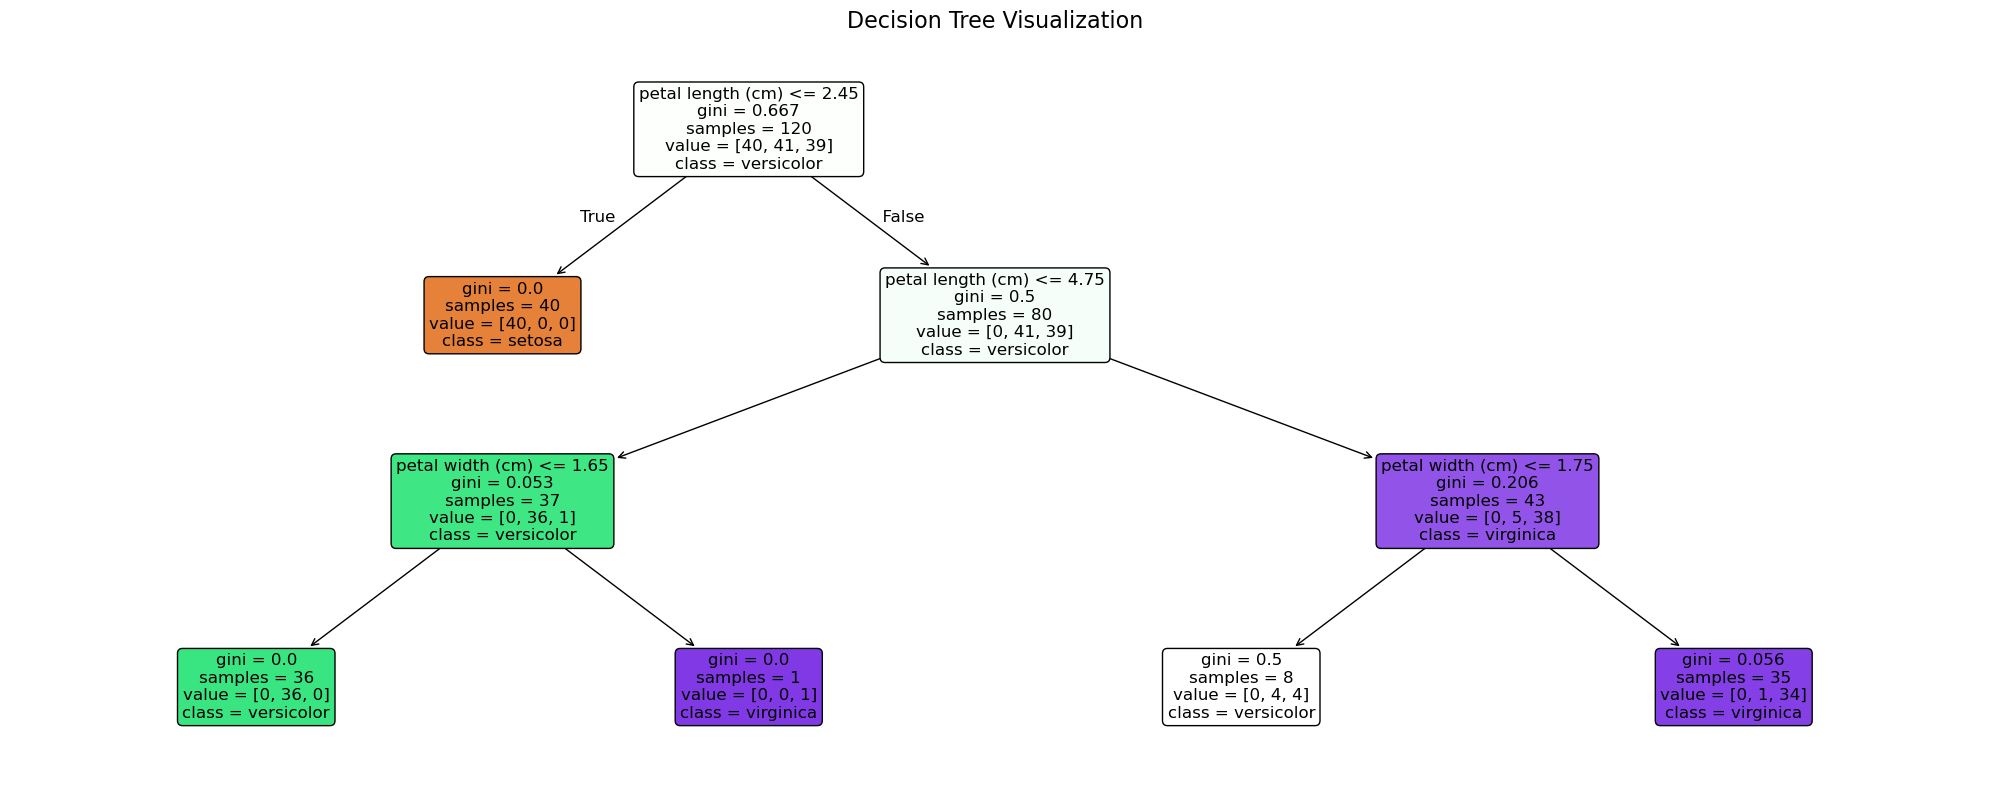

In [9]:
# THE BEST PART — Visualize the actual tree!
plt.figure(figsize=(20, 8))
plot_tree(model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Decision Tree Visualization', fontsize=16)
plt.tight_layout()
plt.show()

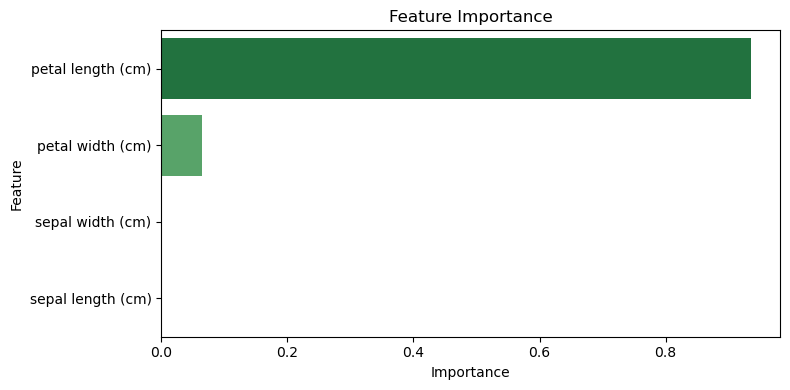

In [13]:
# Feature Importance
importance_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(data=importance_df, x='Importance', y='Feature',
            palette='Greens_r', hue='Feature', legend=False)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [11]:

with open('decision_tree.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved ✅")
# Note: No scaler needed for Decision Trees!

Model saved ✅


## ✅ Summary

| Metric | Value |
|--------|-------|
| Accuracy | ~100% |
| Tree Depth | 3 |
| Number of Leaves | 5 |
| Training Samples | 120 |
| Testing Samples | 30 |

**Key difference from Logistic Regression:**
- No feature scaling needed
- Fully interpretable — you can literally read the tree
- Prone to overfitting if depth not controlled (use max_depth)
- Feature importance tells you which features matter most
- petal length and petal width are the strongest predictors

**Next model → Random Forest (many trees = better accuracy)**